# Credit Card Fraud Detection – Notebook 05  
**Final Model Comparison + Interpretability (SHAP)**

Contents:
- Threshold tuning examples
- SHAP explanations on best model (XGBoost class weights)
- Summary table & business insights

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import xgboost as xgb

# ─── Load saved anomaly scores ───
iso_scores  = np.load('../data/processed/scores/iso_forest_anomaly_scores.npy')
ae_errors   = np.load('../data/processed/scores/autoencoder_recon_errors.npy')
y_test      = np.load('../data/processed/scores/iso_forest_y_test.npy')  

# ─── Load best XGBoost model ───
model_xgb = joblib.load('../models/xgboost_class_weights_best.joblib')

# ─── Load test data for SHAP (need features) ───
X_test = np.load('../data/processed/X_test.npy')

In [9]:
# If you saved column names or prefer DataFrame
df_test = pd.read_csv('../data/raw/creditcard.csv')  # or processed version
X_test_df = df_test.drop('Class', axis=1)
column_names_list = X_test_df.columns.tolist()
print(column_names_list)


['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


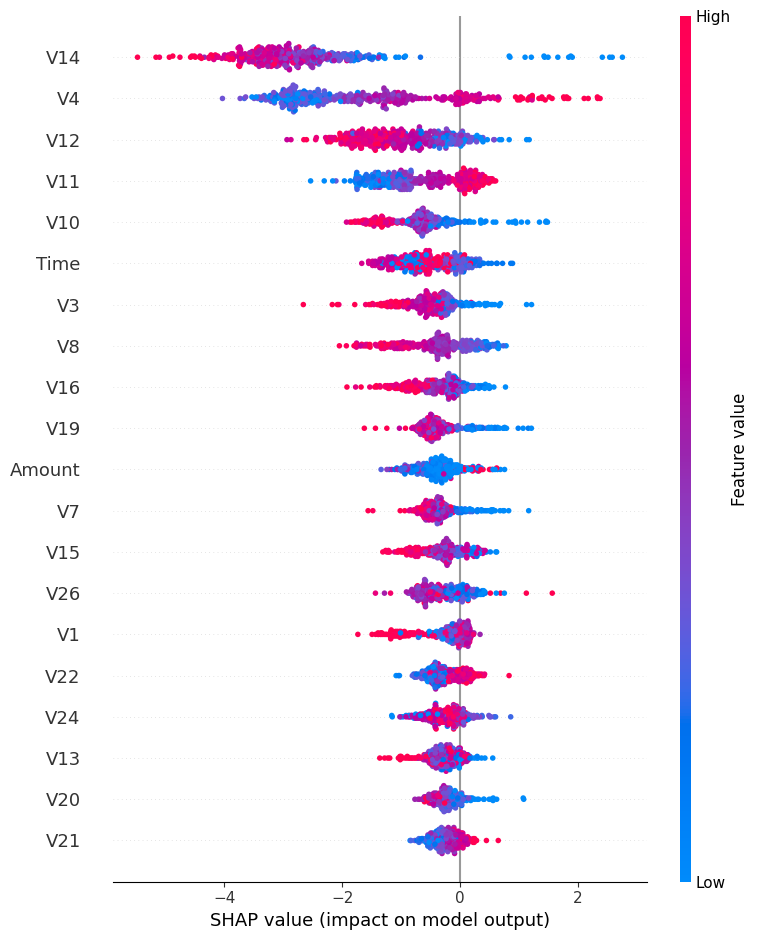

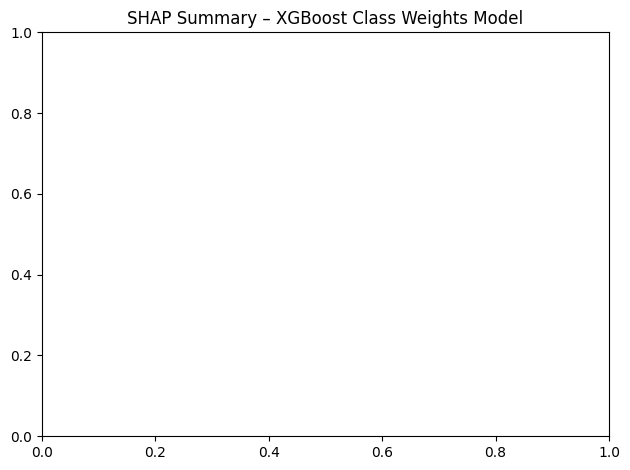

In [10]:

X_sample = shap.utils.sample(X_test, 500, random_state=42)

shap_values = explainer.shap_values(X_sample)


# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(model_xgb)

# Sample for speed
X_sample = X_test[np.random.choice(X_test.shape[0], 400, replace=False)]

# Compute
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample,
                  feature_names= column_names_list)

plt.title("SHAP Summary – XGBoost Class Weights Model")
plt.tight_layout()
plt.show()

In [12]:
comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'Autoencoder', 'XGBoost (best - class weights)'],
    'Type': ['Unsupervised', 'Unsupervised', 'Supervised'],
    'PR-AUC': [0.1717, 0.6454, 0.8800],
    'Separation Ratio / Notes': ['~10–30×', '121×', 'N/A - high precision/recall balance'],
    'Training Requirement': ['None (labels optional)', 'Normal data only', 'Labeled data + imbalance handling']
})

print(comparison.round(4).to_markdown(index=False))

| Model                          | Type         |   PR-AUC | Separation Ratio / Notes            | Training Requirement              |
|:-------------------------------|:-------------|---------:|:------------------------------------|:----------------------------------|
| Isolation Forest               | Unsupervised |   0.1717 | ~10–30×                             | None (labels optional)            |
| Autoencoder                    | Unsupervised |   0.6454 | 121×                                | Normal data only                  |
| XGBoost (best - class weights) | Supervised   |   0.88   | N/A - high precision/recall balance | Labeled data + imbalance handling |
